# Greedy Grouped Incentive Approximation (NEAT Match)

Fast approximation method to match grouped federal incentives to target ZIP-level installation proportions
from a trained model artifact (`Projection.panel_placements`).

This is designed to run much faster than full Pareto evolutionary search.

In [1]:
from pathlib import Path
import pickle
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

repo_root = Path.cwd().resolve()
while repo_root != repo_root.parent and not (repo_root / "Models").exists():
    repo_root = repo_root.parent

if not (repo_root / "Models").exists():
    raise RuntimeError("Could not locate repository root containing 'Models' directory.")

import sys
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from Data.data_load_util import make_dataset
from Simulation.projections_util import create_paper_objectives

plt.style.use("seaborn-v0_8")

In [2]:
# --- Config ---
N_GROUPS_LIST = [1, 2, 3, 5, 8]
INCENTIVE_GRID = list(range(-2000, 8001, 500))
MAX_OUTER_ITERS = 10
RANDOM_SEED = 42
REFERENCE_YEAR_INDEX = -1  # final calibrated year

TARGET_ADOPTION_MODE = "additional_only"
YEARS_TO_SIMULATE = 5
REFERENCE_FEDERAL_INCENTIVE_FOR_CALIBRATION = 0

np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

FEDERAL_CACHE_DIR = repo_root / "Examples" / "model_cache" / "federal"
OUTPUT_DIR = repo_root / "Examples" / "greedy_neat_match_results"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

NEAT_PROJ_PATH = repo_root / "Examples" / "Proportional_NEAT" / "PROJ_softmax_b0p15_large.pkl"

if not FEDERAL_CACHE_DIR.exists():
    raise RuntimeError("Federal cache directory missing. Build federal payload cache first.")
if not NEAT_PROJ_PATH.exists():
    raise RuntimeError(f"Missing NEAT projection file: {NEAT_PROJ_PATH}")

In [3]:
state_behavior_df = pd.read_csv(repo_root / "Models" / "Incentives" / "state_behavior.csv")
zips_df, _, _ = make_dataset(granularity="both", remove_outliers=False, load_dir_prefix=str(repo_root / "Data") + "/")
zip_lookup = zips_df.set_index("region_name")
objectives = create_paper_objectives()

with open(NEAT_PROJ_PATH, "rb") as f:
    neat_proj = pickle.load(f)

if not hasattr(neat_proj, "panel_placements"):
    raise RuntimeError("NEAT artifact missing panel_placements")

target_panels = {}
for k, v in neat_proj.panel_placements.items():
    try:
        z = int(k)
    except Exception:
        continue
    if z in zip_lookup.index:
        target_panels[z] = float(v)

target_total = sum(target_panels.values())
target_prop = {z: (p / target_total if target_total > 0 else 0.0) for z, p in target_panels.items()}

print(f"Target ZIPs: {len(target_prop)}")
print(f"Target total panels (overlap): {target_total:,.0f}")

Target ZIPs: 10421
Target total panels (overlap): 2,000,000


In [4]:
def build_target_adoption_curve(base_adoption, annual_increment, years_total, mode):
    out = []
    for year in range(1, years_total + 1):
        if mode == "absolute_total":
            val = base_adoption + year * annual_increment
        else:
            val = year * annual_increment
        out.append(float(np.clip(val, 0.0, 1.0)))
    return out

def required_incentives(payload, cutoff):
    return payload["installation_cost"] - payload["yearly_savings_coeff"] * cutoff

def eval_cutoff(payloads, cutoff, threshold):
    vals = []
    for p in payloads:
        req = required_incentives(p, cutoff)
        vals.append(float(np.mean(req <= threshold)))
    return float(np.mean(vals)) if vals else 0.0

def calibrate_cutoffs(payloads, targets, threshold, lower=0.25, upper=30.0, steps=28):
    cutoffs = []
    prev = lower
    for t in targets:
        lo, hi = prev, upper
        if eval_cutoff(payloads, hi, threshold) < t:
            cutoffs.append(hi)
            prev = hi
            continue
        if eval_cutoff(payloads, lo, threshold) >= t:
            cutoffs.append(lo)
            prev = lo
            continue
        for _ in range(steps):
            mid = 0.5 * (lo + hi)
            if eval_cutoff(payloads, mid, threshold) < t:
                lo = mid
            else:
                hi = mid
        cutoffs.append(hi)
        prev = hi
    return cutoffs

def load_state_payloads(cache_dir):
    state_payloads = {}
    for p in sorted(cache_dir.glob("zip_payloads_*.pkl")):
        parts = p.stem.split("_")
        if len(parts) < 3:
            continue
        st = parts[2]
        with open(p, "rb") as f:
            cached = pickle.load(f)
        payloads = cached.get("payloads", [])
        if payloads:
            if st not in state_payloads or len(payloads) > len(state_payloads[st]):
                state_payloads[st] = payloads
    return state_payloads

state_payloads = load_state_payloads(FEDERAL_CACHE_DIR)
state_cutoffs = {}

for st in tqdm(sorted(state_payloads.keys()), desc="Calibrate state cutoffs", unit="state"):
    row = state_behavior_df[state_behavior_df["State code"] == st]
    if row.empty:
        continue
    row = row.iloc[0]
    curve = build_target_adoption_curve(
        float(row["prop_adopted_status_quo"][1:-1]),
        float(row["prop_adopted_per_year_average"]),
        YEARS_TO_SIMULATE,
        TARGET_ADOPTION_MODE,
    )
    th = -REFERENCE_FEDERAL_INCENTIVE_FOR_CALIBRATION
    state_cutoffs[st] = calibrate_cutoffs(state_payloads[st], curve, th)

print(f"Calibrated states: {len(state_cutoffs)}")

Calibrate state cutoffs: 100%|██████████| 50/50 [00:13<00:00,  3.67state/s]

Calibrated states: 50


In [5]:
# Build ZIP working table and precompute predicted panels per incentive (fast lookup)
rows = []
for st, payloads in state_payloads.items():
    if st not in state_cutoffs:
        continue
    cutoff = state_cutoffs[st][REFERENCE_YEAR_INDEX]
    for p in payloads:
        z = int(p["zip"])
        if z not in zip_lookup.index:
            continue
        qualified = float(zip_lookup.loc[z, "count_qualified"])
        req = required_incentives(p, cutoff)
        pred_panels_by_incentive = {}
        for inc in INCENTIVE_GRID:
            # inc is literal policy amount; adoption condition compares needed subsidy directly.
            adopt = float(np.mean(req <= inc))
            pred_panels_by_incentive[inc] = max(0.0, adopt * qualified)
        rows.append(
            {
                "zip": z,
                "state_code": st,
                "count_qualified": qualified,
                "target_prop": float(target_prop.get(z, 0.0)),
                "pred_panels_by_incentive": pred_panels_by_incentive,
            }
        )

work_df = pd.DataFrame(rows)
print(f"Working ZIP count: {len(work_df)}")

Working ZIP count: 10475


In [6]:
DEBUG_LOG_PATH = repo_root / "debug-8ac60d.log"
DEBUG_SESSION_ID = "8ac60d"
DEBUG_RUN_ID = f"greedy_run_{int(time.time())}"

import json

def _debug_log(hypothesis_id, location, message, data):
    payload = {
        "sessionId": DEBUG_SESSION_ID,
        "runId": DEBUG_RUN_ID,
        "hypothesisId": hypothesis_id,
        "location": location,
        "message": message,
        "data": data,
        "timestamp": int(time.time() * 1000),
    }
    with open(DEBUG_LOG_PATH, "a", encoding="utf-8") as f:
        f.write(json.dumps(payload) + "\n")

# #region agent log
_debug_log(
    "H4",
    "greedy_neat_match_grouping.ipynb:cell7",
    "target proportion sparsity",
    {
        "zip_count": int(len(work_df)),
        "nonzero_target_count": int((work_df["target_prop"] > 0).sum()),
        "target_prop_sum": float(work_df["target_prop"].sum()),
        "target_prop_p99": float(np.percentile(work_df["target_prop"], 99)),
    },
)
# #endregion

# #region agent log
if len(work_df) > 0:
    _sample = work_df.iloc[0]
    _debug_log(
        "H1",
        "greedy_neat_match_grouping.ipynb:cell7",
        "predicted panels response to incentive grid for sample zip",
        {
            "zip": int(_sample["zip"]),
            "panels_at_min_incentive": float(_sample["pred_panels_by_incentive"][min(INCENTIVE_GRID)]),
            "panels_at_max_incentive": float(_sample["pred_panels_by_incentive"][max(INCENTIVE_GRID)]),
        },
    )
# #endregion

def evaluate_group_strategy(df, group_ids, group_incentives, log_eval=False):
    pred_panels = {}
    for i, r in enumerate(df.itertuples(index=False)):
        g = int(group_ids[i])
        inc = group_incentives[g]
        pred_panels[int(r.zip)] = float(r.pred_panels_by_incentive[inc])

    total_pred = sum(pred_panels.values())
    if total_pred <= 0:
        return {
            "mae": 1.0,
            "rmse": 1.0,
            "match_score": 0.0,
            "placements": pred_panels,
        }

    pred_prop = {z: p / total_pred for z, p in pred_panels.items()}
    keys = sorted(set(pred_prop.keys()) | set(df["zip"].tolist()))
    target_map = {int(r.zip): float(r.target_prop) for r in df.itertuples(index=False)}
    diffs = np.array([pred_prop.get(k, 0.0) - target_map.get(k, 0.0) for k in keys], dtype=float)
    mae = float(np.mean(np.abs(diffs)))
    rmse = float(np.sqrt(np.mean(diffs * diffs)))
    score = float(max(0.0, 1.0 - mae * len(keys) / 2.0))

    if log_eval:
        # #region agent log
        _debug_log(
            "H3",
            "greedy_neat_match_grouping.ipynb:cell7",
            "global evaluation snapshot",
            {
                "group_incentives": [int(x) for x in group_incentives],
                "total_pred": float(total_pred),
                "mae": mae,
                "rmse": rmse,
                "match_score": score,
            },
        )
        # #endregion

    return {
        "mae": mae,
        "rmse": rmse,
        "match_score": score,
        "placements": pred_panels,
    }

def greedy_group_match(df, n_groups, max_iters=8):
    rank = pd.qcut(df["target_prop"].rank(method="first"), q=n_groups, labels=False, duplicates="drop")
    group_ids = rank.to_numpy(dtype=int)
    if group_ids.max() + 1 < n_groups:
        group_ids = np.random.randint(0, n_groups, size=len(df))

    starts = np.linspace(0, len(INCENTIVE_GRID) - 1, n_groups).round().astype(int)
    group_incentives = [INCENTIVE_GRID[i] for i in starts]

    best_eval = evaluate_group_strategy(df, group_ids, group_incentives, log_eval=True)

    # #region agent log
    _debug_log(
        "H2",
        "greedy_neat_match_grouping.ipynb:cell7",
        "initial state before iterations",
        {
            "n_groups": int(n_groups),
            "initial_incentives": [int(x) for x in group_incentives],
            "initial_mae": float(best_eval["mae"]),
        },
    )
    # #endregion

    for iter_idx in tqdm(range(max_iters), desc=f"Greedy optimize n={n_groups}", leave=False):
        changed = False

        # Use current total prediction to align local assignment to proportion-space loss.
        current_eval = evaluate_group_strategy(df, group_ids, group_incentives)
        current_total_pred = float(sum(current_eval["placements"].values()))
        denom = max(current_total_pred, 1e-9)

        sampled_losses = []
        for i, r in enumerate(df.itertuples(index=False)):
            cur_g = int(group_ids[i])
            cur_best = cur_g
            cur_best_loss = None
            for g in range(n_groups):
                inc = group_incentives[g]
                local_pred = float(r.pred_panels_by_incentive[inc])
                local_pred_prop = local_pred / denom
                loss = abs(local_pred_prop - float(r.target_prop))
                if i < 5:
                    sampled_losses.append({"zip": int(r.zip), "group": int(g), "inc": int(inc), "local_pred": local_pred, "local_pred_prop": local_pred_prop, "target_prop": float(r.target_prop), "loss": float(loss)})
                if (cur_best_loss is None) or (loss < cur_best_loss):
                    cur_best_loss = loss
                    cur_best = g
            if cur_best != cur_g:
                group_ids[i] = cur_best
                changed = True

        # #region agent log
        _debug_log(
            "H2",
            "greedy_neat_match_grouping.ipynb:cell7",
            "assignment step sampled losses",
            {
                "iter_idx": int(iter_idx),
                "sampled_losses": sampled_losses[:20],
            },
        )
        # #endregion

        for g in range(n_groups):
            best_inc = group_incentives[g]
            best_mae = None
            mae_by_inc = []
            for inc in INCENTIVE_GRID:
                trial = list(group_incentives)
                trial[g] = inc
                ev = evaluate_group_strategy(df, group_ids, trial)
                mae_by_inc.append({"inc": int(inc), "mae": float(ev["mae"])})
                if (best_mae is None) or (ev["mae"] < best_mae):
                    best_mae = ev["mae"]
                    best_inc = inc

            # #region agent log
            _debug_log(
                "H1",
                "greedy_neat_match_grouping.ipynb:cell7",
                "group update mae landscape",
                {
                    "iter_idx": int(iter_idx),
                    "group": int(g),
                    "selected_inc": int(best_inc),
                    "selected_mae": float(best_mae),
                    "mae_by_inc": mae_by_inc,
                },
            )
            # #endregion

            if best_inc != group_incentives[g]:
                group_incentives[g] = best_inc
                changed = True

        ev_now = evaluate_group_strategy(df, group_ids, group_incentives, log_eval=True)
        if ev_now["mae"] < best_eval["mae"]:
            best_eval = ev_now

        if not changed:
            break

    return group_ids, group_incentives, best_eval

def compute_objectives_from_placements(placements):
    vals = {}
    for obj in objectives:
        vals[obj.name] = float(obj.calc(zips_df, placements))
    return vals

In [7]:
# #region agent log
import json as _json_dbg95
import time as _time_dbg95


def _dbg95(hypothesis_id, location, message, data):
    with open(repo_root / "debug-95c829.log", "a", encoding="utf-8") as _f:
        _f.write(
            _json_dbg95.dumps(
                {
                    "sessionId": "95c829",
                    "hypothesisId": hypothesis_id,
                    "location": location,
                    "message": message,
                    "data": data,
                    "timestamp": int(_time_dbg95.time() * 1000),
                    "runId": "greedy-neat-debug",
                }
            )
            + "\n"
        )


# #endregion

result_rows = []
assignments = {}

for n in tqdm(N_GROUPS_LIST, desc="Run greedy grouped matching", unit="n"):
    t0 = time.time()
    gids, gincs, ev = greedy_group_match(work_df, n_groups=n, max_iters=MAX_OUTER_ITERS)
    placements = ev["placements"]
    obj_vals = compute_objectives_from_placements(placements)
    spending = float(sum(gincs[int(gids[i])] * placements[int(work_df.iloc[i]['zip'])] for i in range(len(work_df))))
    total_panels = float(sum(placements.values()))

    result_rows.append(
        {
            "n_groups": n,
            "group_incentives": str(gincs),
            "match_score": ev["match_score"],
            "match_mae": ev["mae"],
            "match_rmse": ev["rmse"],
            "total_panels": total_panels,
            "total_spending": spending,
            "Carbon Offset": obj_vals.get("Carbon Offset", np.nan),
            "Energy Generation": obj_vals.get("Energy Potential", np.nan),
            "Racial Equity": obj_vals.get("Racial Equity", np.nan),
            "Income Equity": obj_vals.get("Income Equity", np.nan),
            "elapsed_sec": time.time() - t0,
        }
    )

    # #region agent log
    _row = result_rows[-1]
    _sp = float(_row["total_spending"])
    _dbg95(
        "H1",
        "greedy_neat_match_grouping.ipynb:cell7:per_n",
        "calibration-year efficiency vs n",
        {
            "n_groups": int(n),
            "match_mae": float(_row["match_mae"]),
            "match_score": float(_row["match_score"]),
            "total_spending": _sp,
            "total_panels": float(_row["total_panels"]),
            "carbon_per_dollar": float(_row["Carbon Offset"] / _sp) if _sp > 0 else None,
            "energy_per_dollar": float(_row["Energy Generation"] / _sp) if _sp > 0 else None,
            "carbon_raw": float(_row["Carbon Offset"]),
            "energy_raw": float(_row["Energy Generation"]),
        },
    )
    # #endregion

    assign_df = work_df[["zip", "state_code", "target_prop"]].copy()
    assign_df["group_id"] = gids
    assign_df["group_incentive"] = [gincs[g] for g in gids]
    assign_df["pred_panels"] = [placements[int(z)] for z in assign_df["zip"]]
    assignments[n] = assign_df
    assign_df.to_csv(OUTPUT_DIR / f"greedy_assignments_n{n}.csv", index=False)

results_df = pd.DataFrame(result_rows).sort_values("n_groups").reset_index(drop=True)
results_df.to_csv(OUTPUT_DIR / "greedy_summary.csv", index=False)

# #region agent log
_spd = results_df["total_spending"].replace(0, np.nan)
_cpd = results_df["Carbon Offset"] / _spd
_epd = results_df["Energy Generation"] / _spd
_mae = results_df["match_mae"].to_numpy(dtype=float)
_ng = results_df["n_groups"].to_numpy(dtype=float)
_cpv = _cpd.to_numpy(dtype=float)
_epv = _epd.to_numpy(dtype=float)


def _safe_corr(a, b):
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() < 2:
        return None
    return float(np.corrcoef(a[m], b[m])[0, 1])


_dbg95(
    "H2",
    "greedy_neat_match_grouping.ipynb:cell7:summary",
    "correlation: n and MAE vs $-normalized metrics (calibration year)",
    {
        "corrcoef_n_carbonPerDollar": _safe_corr(_ng, _cpv),
        "corrcoef_n_energyPerDollar": _safe_corr(_ng, _epv),
        "corrcoef_mae_carbonPerDollar": _safe_corr(_mae, _cpv),
        "corrcoef_mae_energyPerDollar": _safe_corr(_mae, _epv),
        "per_n": results_df[
            [
                "n_groups",
                "match_mae",
                "total_spending",
                "Carbon Offset",
                "Energy Generation",
            ]
        ].to_dict(orient="records"),
    },
)
_neat_obj = compute_objectives_from_placements(target_panels)
_dbg95(
    "H5",
    "greedy_neat_match_grouping.ipynb:cell7:neat_ref",
    "NEAT static placement objectives (no spend term)",
    {k: float(v) for k, v in _neat_obj.items() if isinstance(v, (int, float, np.floating)) and np.isfinite(v)},
)
# #endregion

display(results_df)

Run greedy grouped matching: 100%|██████████| 5/5 [02:06<00:00, 25.31s/n]


,n_groups,group_incentives,match_score,match_mae,match_rmse,total_panels,total_spending,Carbon Offset,Energy Generation,Racial Equity,Income Equity,elapsed_sec
0,1,[4500],0.405058,0.000114,0.000274,5.319224e+06,2.393651e+10,814802.635736,6.393951e+09,1.474383,1.333286,12.843079
1,2,"[500, 8000]",0.597783,0.000077,0.000167,3.651661e+06,6.862154e+09,650803.898709,4.233284e+09,1.482384,1.500457,19.207947
2,3,"[-2000, 5000, 8000]",0.672156,0.000063,0.000151,2.263362e+06,3.291205e+09,419603.121307,2.635020e+09,1.456274,1.546313,22.857240
3,5,"[-2000, 1500, 4000, 6500, 8000]",0.720832,0.000053,0.000131,1.851967e+06,4.590343e+09,333669.082849,2.159662e+09,1.421856,1.555969,30.308566
4,8,"[-2000, -1000, 500, 2000, 3500, 5000, 6500, 8000]",0.748261,0.000048,0.000126,1.941892e+06,4.917753e+09,351186.316266,2.263982e+09,1.436459,1.559690,41.184034


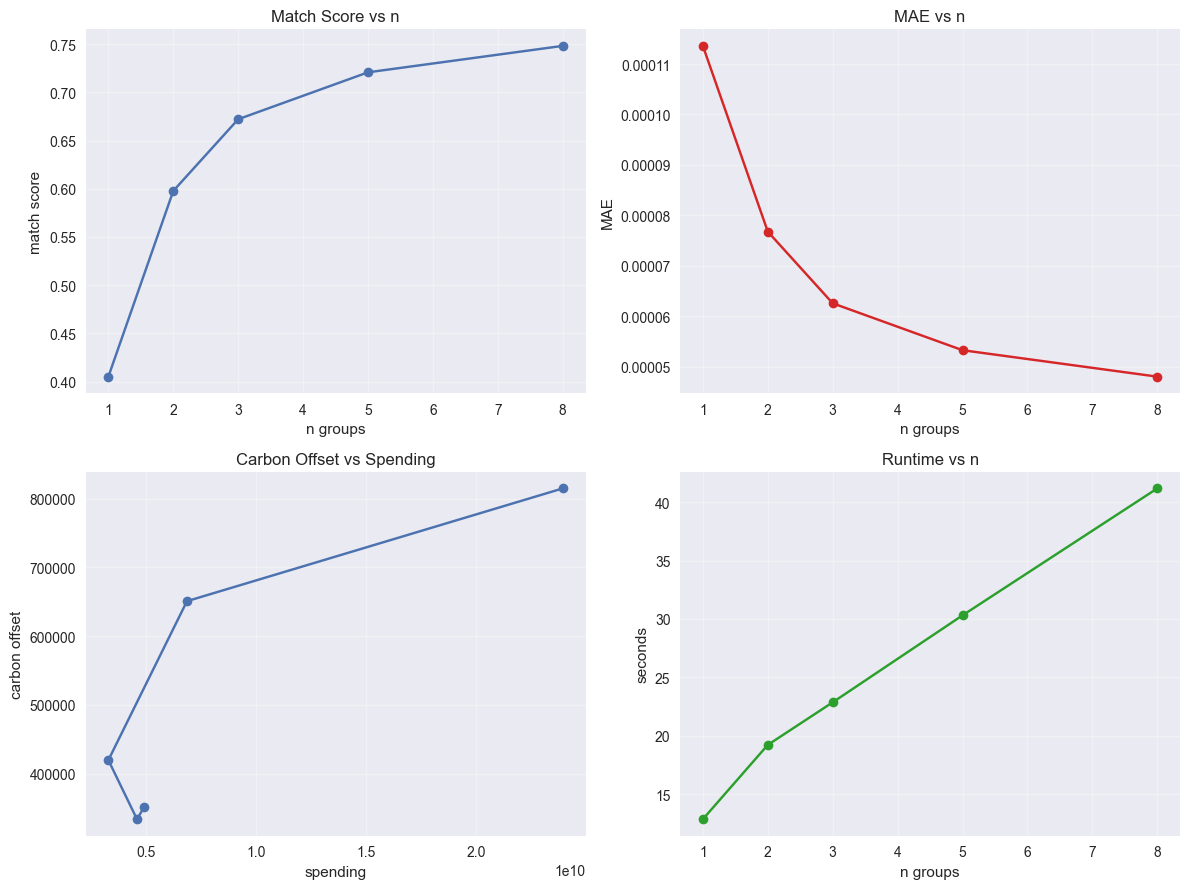

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

axes[0, 0].plot(results_df["n_groups"], results_df["match_score"], marker="o")
axes[0, 0].set_title("Match Score vs n")
axes[0, 0].set_xlabel("n groups")
axes[0, 0].set_ylabel("match score")
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(results_df["n_groups"], results_df["match_mae"], marker="o", color="tab:red")
axes[0, 1].set_title("MAE vs n")
axes[0, 1].set_xlabel("n groups")
axes[0, 1].set_ylabel("MAE")
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(results_df["total_spending"], results_df["Carbon Offset"], marker="o")
axes[1, 0].set_title("Carbon Offset vs Spending")
axes[1, 0].set_xlabel("spending")
axes[1, 0].set_ylabel("carbon offset")
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(results_df["n_groups"], results_df["elapsed_sec"], marker="o", color="tab:green")
axes[1, 1].set_title("Runtime vs n")
axes[1, 1].set_xlabel("n groups")
axes[1, 1].set_ylabel("seconds")
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Match to NEAT (Proportional_NEAT): ZIP proportions + aggregate objectives vs trained reference
neat_obj_ref = compute_objectives_from_placements(target_panels)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

n_vals = results_df["n_groups"].values
blue_cmap = plt.cm.Blues
line_colors = [blue_cmap(0.35 + 0.55 * i / max(1, len(n_vals) - 1)) for i in range(len(n_vals))]

# Left: deviation of greedy ZIP proportions from NEAT model proportions (same metric as optimization)
ax = axes[0]
ax.plot(results_df["n_groups"], results_df["match_score"], color="0.75", linewidth=1, zorder=1)
for i, (_, row) in enumerate(results_df.iterrows()):
    ax.scatter(
        row["n_groups"],
        row["match_score"],
        color=line_colors[i],
        s=80,
        zorder=3,
        edgecolors="white",
        linewidths=0.8,
    )
ax.set_xlabel("n groups")
ax.set_ylabel("match score", color="tab:blue")
ax.tick_params(axis="y", labelcolor="tab:blue")

ax_t = ax.twinx()
ax_t.plot(results_df["n_groups"], results_df["match_mae"], marker="s", color="tab:orange", label="MAE")
ax_t.plot(results_df["n_groups"], results_df["match_rmse"], marker="^", color="tab:red", label="RMSE")
ax_t.set_ylabel("MAE / RMSE (prop. deviation vs NEAT)")
ax_t.legend(loc="upper right", fontsize=9)

ax.set_title("ZIP proportion alignment vs NEAT `panel_placements`")
ax.grid(True, alpha=0.3)

# Right: greedy aggregate objectives vs objectives from NEAT reference placements (static panel totals)
ax = axes[1]
key_map = [
    ("Carbon Offset", "Carbon Offset"),
    ("Energy Generation", "Energy Potential"),
    ("Racial Equity", "Racial Equity"),
    ("Income Equity", "Income Equity"),
]
for disp_name, obj_key in key_map:
    denom = neat_obj_ref.get(obj_key, np.nan)
    if denom is None or (isinstance(denom, (float, np.floating)) and (np.isnan(denom) or abs(float(denom)) < 1e-30)):
        continue
    ax.plot(results_df["n_groups"], results_df[disp_name] / float(denom), marker="o", label=disp_name)

ax.axhline(1.0, linestyle="--", color="gray", alpha=0.7)
ax.set_xlabel("n groups")
ax.set_ylabel("objective / NEAT reference")
ax.set_title("Aggregate objectives vs NEAT placement objectives")
ax.legend(loc="best", fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


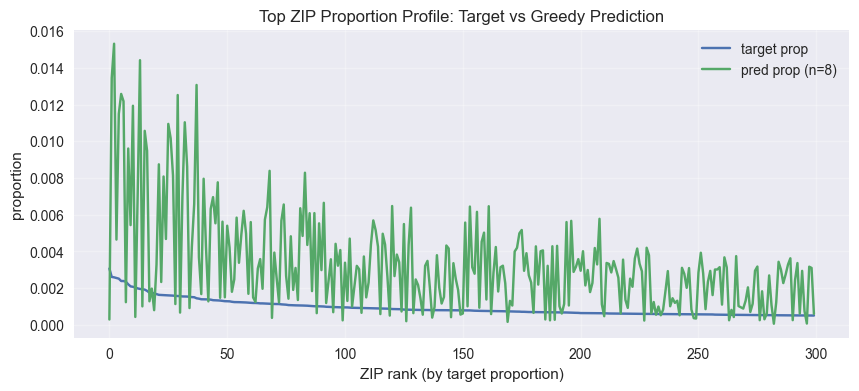

,zip,state_code,group_id,group_incentive,target_prop,pred_prop
8850,38141,TN,7,8000,0.003067,0.000290
9585,79424,TX,6,6500,0.002609,0.013448
410,85262,AZ,6,6500,0.002587,0.015315
5259,63131,MO,7,8000,0.002551,0.004644
9567,79119,TX,7,8000,0.002515,0.011495
1658,80132,CO,7,8000,0.002387,0.012579
1755,80921,CO,7,8000,0.002386,0.012180
5219,63034,MO,7,8000,0.002347,0.001233
9584,79423,TX,6,6500,0.002207,0.009605
9566,79118,TX,6,6500,0.002095,0.005433


In [9]:
# Visualization of target vs predicted ZIP proportions for a chosen n
N_SHOW = N_GROUPS_LIST[-1]
adf = assignments[N_SHOW].copy().sort_values("target_prop", ascending=False).head(300)
pred_total = adf["pred_panels"].sum()
adf["pred_prop"] = adf["pred_panels"] / pred_total if pred_total > 0 else 0.0

plt.figure(figsize=(10, 4))
plt.plot(adf["target_prop"].values, label="target prop")
plt.plot(adf["pred_prop"].values, label=f"pred prop (n={N_SHOW})")
plt.title("Top ZIP Proportion Profile: Target vs Greedy Prediction")
plt.xlabel("ZIP rank (by target proportion)")
plt.ylabel("proportion")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

display(adf[["zip", "state_code", "group_id", "group_incentive", "target_prop", "pred_prop"]].head(20))

In [10]:
import ast

# Build quick lookup maps for yearly evaluation
payload_by_zip = {}
for st, payloads in state_payloads.items():
    for p in payloads:
        payload_by_zip[int(p["zip"])] = p

qualified_by_zip = {int(r.zip): float(r.count_qualified) for r in work_df.itertuples(index=False)}
state_by_zip = {int(r.zip): r.state_code for r in work_df.itertuples(index=False)}


def evaluate_year_for_assignment(assign_df, year_idx):
    placements = {}
    spending = 0.0

    for r in assign_df.itertuples(index=False):
        z = int(r.zip)
        if z not in payload_by_zip:
            continue

        st = state_by_zip[z]
        cutoff = state_cutoffs[st][year_idx]
        inc = float(r.group_incentive)

        req = required_incentives(payload_by_zip[z], cutoff)
        adopt = float(np.mean(req <= inc))
        panels = max(0.0, adopt * qualified_by_zip[z])

        placements[z] = panels
        spending += inc * panels

    obj_vals = compute_objectives_from_placements(placements)
    return {
        "Carbon Offset": float(obj_vals.get("Carbon Offset", np.nan)),
        "Energy Generation": float(obj_vals.get("Energy Potential", np.nan)),
        "Racial Equity": float(obj_vals.get("Racial Equity", np.nan)),
        "Income Equity": float(obj_vals.get("Income Equity", np.nan)),
        "Total Cost": float(spending),
    }


# Yearly trajectories for each n solution found by greedy optimizer
yearly_rows = []
for n in N_GROUPS_LIST:
    assign_df = assignments[n].copy()
    for year_idx in range(YEARS_TO_SIMULATE):
        metrics = evaluate_year_for_assignment(assign_df, year_idx)
        yearly_rows.append(
            {
                "n_groups": int(n),
                "year": int(year_idx + 1),
                **metrics,
            }
        )

yearly_metrics_df = pd.DataFrame(yearly_rows).sort_values(["n_groups", "year"]).reset_index(drop=True)

# #region agent log
_yc = yearly_metrics_df["Total Cost"].replace(0, np.nan)
_ycpd = (yearly_metrics_df["Carbon Offset"] / _yc).to_numpy()
_yepd = (yearly_metrics_df["Energy Generation"] / _yc).to_numpy()
_dbg95(
    "H3",
    "greedy_neat_match_grouping.ipynb:cell11:yearly",
    "per year carbon/energy per dollar (all n x year rows)",
    {
        "rows": yearly_metrics_df.assign(
            carbon_per_dollar=yearly_metrics_df["Carbon Offset"] / _yc,
            energy_per_dollar=yearly_metrics_df["Energy Generation"] / _yc,
        )[["n_groups", "year", "Total Cost", "carbon_per_dollar", "energy_per_dollar"]].to_dict(orient="records"),
    },
)
_dbg95(
    "H4",
    "greedy_neat_match_grouping.ipynb:cell11:cost_by_n",
    "mean yearly Total Cost by n (spend may outpace raw objectives)",
    {
        "mean_total_cost_by_n": yearly_metrics_df.groupby("n_groups")["Total Cost"].mean().to_dict(),
        "sum_total_cost_by_n": yearly_metrics_df.groupby("n_groups")["Total Cost"].sum().to_dict(),
    },
)
# #endregion

display(yearly_metrics_df.head())

# Build status-quo yearly series (0 incentive for all ZIPs)
status_rows = []
for year_idx in range(YEARS_TO_SIMULATE):
    placements = {}
    for z in qualified_by_zip:
        st = state_by_zip[z]
        cutoff = state_cutoffs[st][year_idx]
        req = required_incentives(payload_by_zip[z], cutoff)
        adopt = float(np.mean(req <= 0.0))
        placements[z] = max(0.0, adopt * qualified_by_zip[z])

    obj_vals = compute_objectives_from_placements(placements)
    status_rows.append(
        {
            "year": int(year_idx + 1),
            "Carbon Offset": float(obj_vals.get("Carbon Offset", np.nan)),
            "Energy Generation": float(obj_vals.get("Energy Potential", np.nan)),
            "Racial Equity": float(obj_vals.get("Racial Equity", np.nan)),
            "Income Equity": float(obj_vals.get("Income Equity", np.nan)),
        }
    )

status_df = pd.DataFrame(status_rows)

# Ratio metrics for highest n vs status quo over years
n_max = max(N_GROUPS_LIST)
high_n_df = yearly_metrics_df[yearly_metrics_df["n_groups"] == n_max].copy().sort_values("year")
ratio_df = high_n_df[["year", "Carbon Offset", "Energy Generation", "Racial Equity", "Income Equity"]].copy()

for col in ["Carbon Offset", "Energy Generation", "Racial Equity", "Income Equity"]:
    denom = status_df[col].replace(0, np.nan)
    ratio_df[col] = ratio_df[col].values / denom.values

display(ratio_df)

,n_groups,year,Carbon Offset,Energy Generation,Racial Equity,Income Equity,Total Cost
0,1,1,261874.809927,2.029740e+09,1.507577,1.260535,7.922893e+09
1,1,2,390615.250812,2.978727e+09,1.504631,1.224474,1.164902e+10
2,1,3,500836.253959,3.847820e+09,1.491956,1.217322,1.495525e+10
3,1,4,623202.175993,4.832089e+09,1.481927,1.239499,1.853528e+10
4,1,5,814802.635736,6.393951e+09,1.474383,1.333286,2.393651e+10


,year,Carbon Offset,Energy Generation,Racial Equity,Income Equity
20,1,2.392154,1.750086,1.022456,1.063372
21,2,1.817661,1.369837,0.977917,1.048289
22,3,1.634295,1.255153,0.956677,1.086484
23,4,1.585034,1.245304,0.942387,1.137976
24,5,1.598450,1.279527,0.942820,1.196314


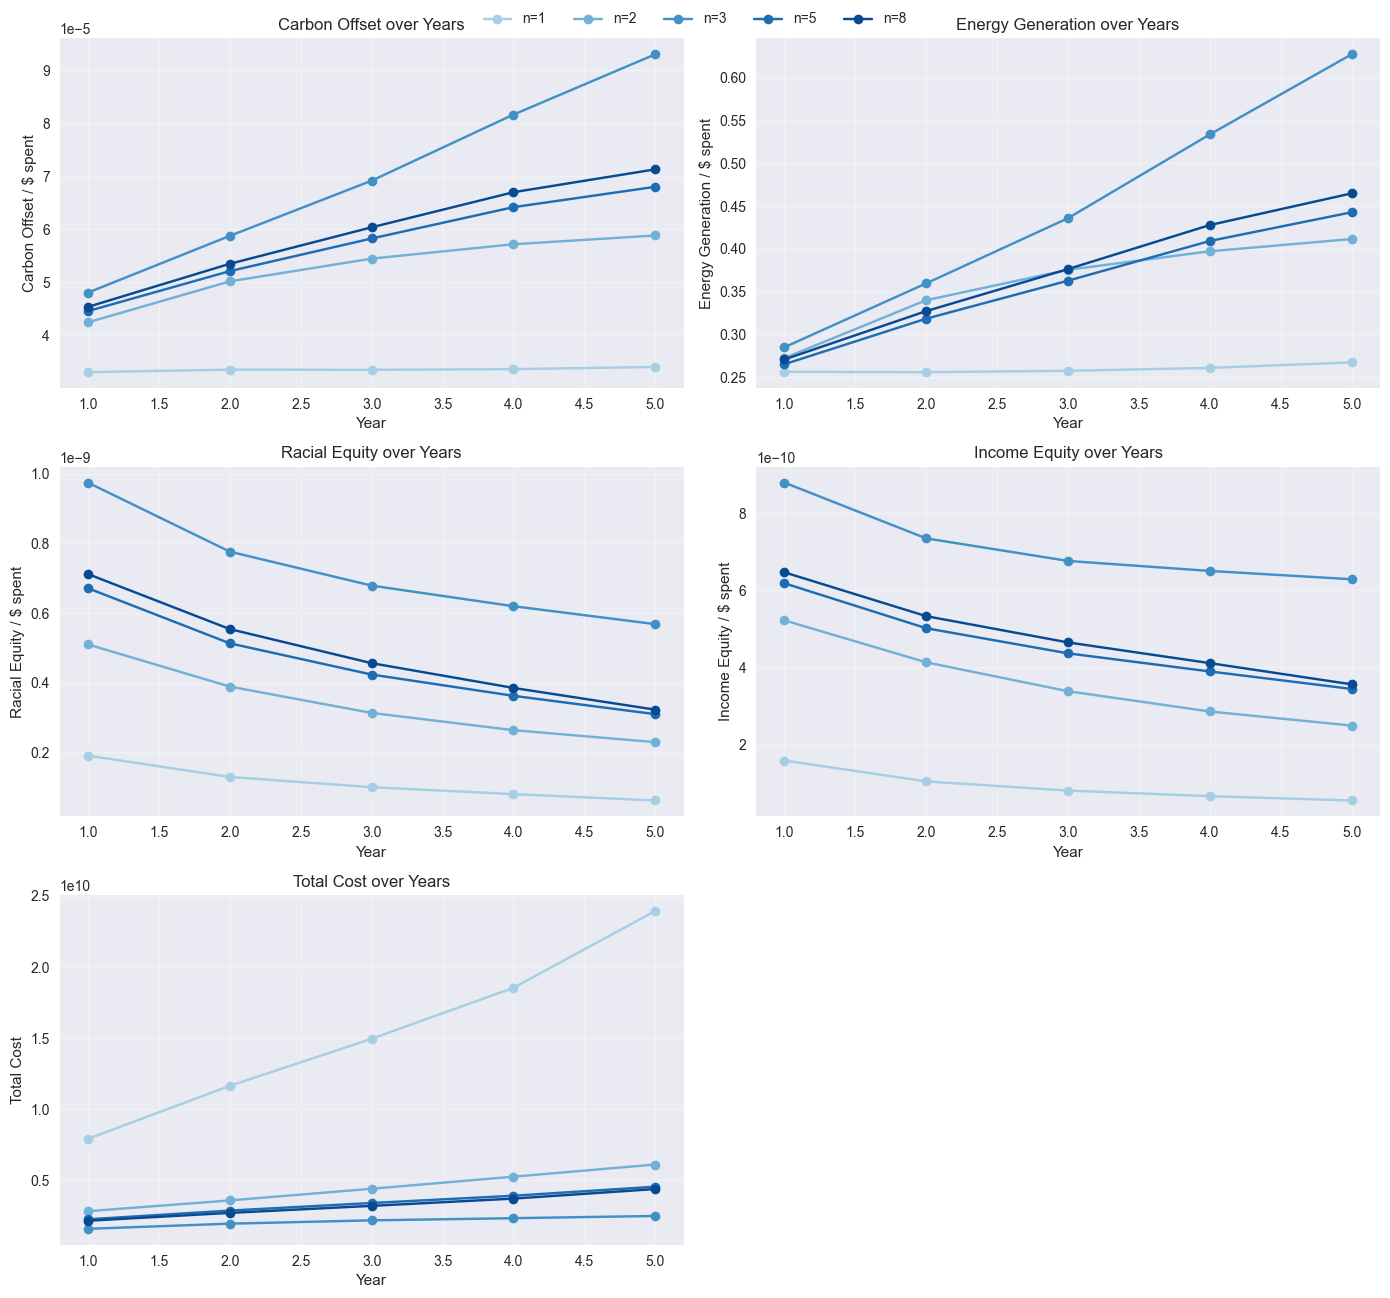

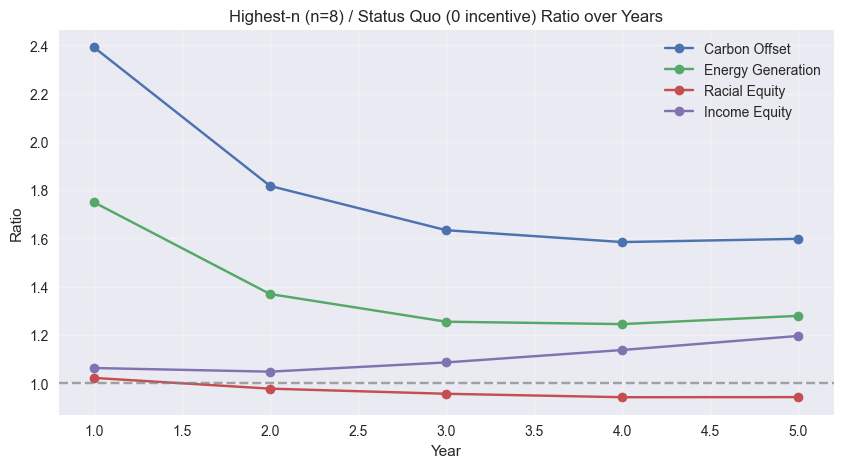

In [12]:
# Plot years vs each metric, with one line per n
metric_cols = ["Carbon Offset", "Energy Generation", "Racial Equity", "Income Equity", "Total Cost"]
fig, axes = plt.subplots(3, 2, figsize=(14, 13))
axes = axes.flatten()

n_values = sorted(yearly_metrics_df["n_groups"].unique())
blue_cmap = plt.cm.Blues
line_colors = [blue_cmap(0.35 + 0.55 * i / max(1, len(n_values) - 1)) for i in range(len(n_values))]

# NEAT-prop reference objectives (from target placements)
neat_obj_vals = compute_objectives_from_placements(target_panels)
neat_ref = {
    "Carbon Offset": float(neat_obj_vals.get("Carbon Offset", np.nan)),
    "Energy Generation": float(neat_obj_vals.get("Energy Potential", np.nan)),
    "Racial Equity": float(neat_obj_vals.get("Racial Equity", np.nan)),
    "Income Equity": float(neat_obj_vals.get("Income Equity", np.nan)),
}
years = sorted(yearly_metrics_df["year"].unique())
yearly_mean_cost = yearly_metrics_df.groupby("year")["Total Cost"].mean().reindex(years)

for i, metric in enumerate(metric_cols):
    ax = axes[i]
    for n, c in zip(n_values, line_colors):
        g = yearly_metrics_df[yearly_metrics_df["n_groups"] == n].sort_values("year")
        y_vals = g[metric] if metric == "Total Cost" else g[metric] / g["Total Cost"]
        ax.plot(g["year"], y_vals, marker="o", color=c, label=f"n={n}")

    # if metric != "Total Cost" and metric in neat_ref:
    #     neat_y = neat_ref[metric] / yearly_mean_cost.values
    #     ax.plot(
    #         years,
    #         neat_y,
    #         linestyle=":",
    #         linewidth=2.5,
    #         color="#555555",
    #         label="Neat-prop",
    #     )

    ax.set_title(f"{metric} over Years")
    ax.set_xlabel("Year")
    ax.set_ylabel(metric if metric == "Total Cost" else f"{metric} / $ spent")
    ax.grid(True, alpha=0.3)

# hide the unused subplot slot
axes[-1].axis("off")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=min(len(handles), 6))
plt.tight_layout()
plt.show()

# Ratio plot: highest n vs status quo over years (excluding cost)
plt.figure(figsize=(10, 5))
for metric in ["Carbon Offset", "Energy Generation", "Racial Equity", "Income Equity"]:
    plt.plot(ratio_df["year"], ratio_df[metric], marker="o", label=metric)

plt.axhline(1.0, linestyle="--", color="gray", alpha=0.7)
plt.title(f"Highest-n (n={n_max}) / Status Quo (0 incentive) Ratio over Years")
plt.xlabel("Year")
plt.ylabel("Ratio")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()